# Intro

Starting with public dataset first since it's difficult to get Ghana Open Data Sources. However i'm looking at potential sources such as:

- Energy Commission Ghana -> - https://www.energycom.gov.gh?utm_source=chatgpt.com
- Volta River Authority -> https://www.energycom.gov.gh?utm_source=chatgpt.com
- GRIDCo Ghana->https://www.gridcogh.com?utm_source=chatgpt.com

However, publicly available historical demand data may be limited and so i'm using the alternative public electricity demand dataset first on Kaggle and once it works, i will look at implementing it for Ghana.

For this project, i will be considering either the:

PJM
- PJM Hourly Energy Consumption Dataset -> https://archive.ics.uci.edu/ml/datasets/ElectricityLoadDiagrams20112014?utm_source=chatgpt.com

or the

Electricity Load Diagrams
- UCI Electricity Load Diagrams Dataset -> https://archive.ics.uci.edu/ml/datasets/ElectricityLoadDiagrams20112014?utm_source=chatgpt.com

Why these dataset?
Because:
- Clean
- Large
- Well-known

for now, i will focus on forecasting, then later adapt methodology to Ghana.

import kagglehub

# Download latest version
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")

print("Path to dataset files:", path)

## Get Data

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")

print("Path to dataset files:", path)

100%|██████████| 11.4M/11.4M [00:00<00:00, 91.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/robikscube/hourly-energy-consumption/versions/3


In [2]:
import os

for file in os.listdir(path):
    print(file)

COMED_hourly.csv
FE_hourly.csv
EKPC_hourly.csv
PJM_Load_hourly.csv
NI_hourly.csv
PJMW_hourly.csv
pjm_hourly_est.csv
est_hourly.paruqet
DUQ_hourly.csv
AEP_hourly.csv
DAYTON_hourly.csv
DEOK_hourly.csv
DOM_hourly.csv
PJME_hourly.csv


## Load PJM Dataset

In [3]:
import pandas as pd

df = pd.read_csv(
    os.path.join(path, "PJM_Load_hourly.csv")
)

df.head()

,Datetime,PJM_Load_MW
0,1998-12-31 01:00:00,29309.0
1,1998-12-31 02:00:00,28236.0
2,1998-12-31 03:00:00,27692.0
3,1998-12-31 04:00:00,27596.0
4,1998-12-31 05:00:00,27888.0


In [4]:
print(f"Shape: {df.shape}")

Shape: (32896, 2)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32896 entries, 0 to 32895
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Datetime     32896 non-null  object 
 1   PJM_Load_MW  32896 non-null  float64
dtypes: float64(1), object(1)
memory usage: 514.1+ KB


In [6]:
df.describe()

,PJM_Load_MW
count,32896.000000
mean,29766.427408
std,5849.769954
min,17461.000000
25%,25473.000000
50%,29655.000000
75%,33073.250000
max,54030.000000


In [7]:
df.isnull().sum()

,0
Datetime,0
PJM_Load_MW,0


In [8]:
df = df.set_index("Datetime")

df.head()

,PJM_Load_MW
Datetime,
1998-12-31 01:00:00,29309.0
1998-12-31 02:00:00,28236.0
1998-12-31 03:00:00,27692.0
1998-12-31 04:00:00,27596.0
1998-12-31 05:00:00,27888.0


## Visualize Electricity Demand

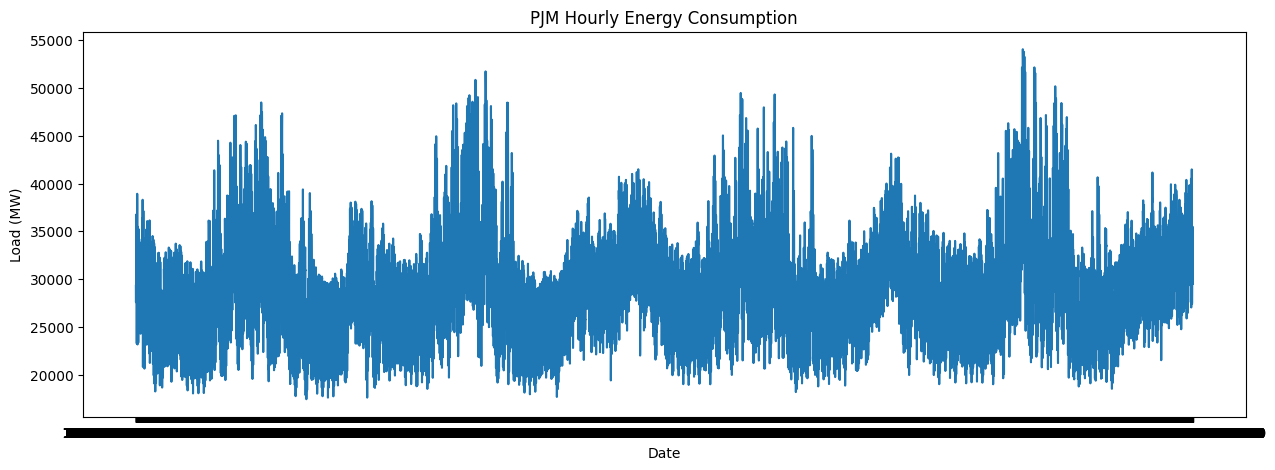

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(df.index, df["PJM_Load_MW"])

plt.title("PJM Hourly Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Load (MW)")

plt.show()

## Create Time-Based Features

In [11]:
df.index = pd.to_datetime(df.index)
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["quarter"] = df.index.quarter
df["month"] = df.index.month
df["year"] = df.index.year
df["dayofyear"] = df.index.dayofyear

df.head()

,PJM_Load_MW,hour,dayofweek,quarter,month,year,dayofyear
Datetime,,,,,,,
1998-12-31 01:00:00,29309.0,1,3,4,12,1998,365
1998-12-31 02:00:00,28236.0,2,3,4,12,1998,365
1998-12-31 03:00:00,27692.0,3,3,4,12,1998,365
1998-12-31 04:00:00,27596.0,4,3,4,12,1998,365
1998-12-31 05:00:00,27888.0,5,3,4,12,1998,365


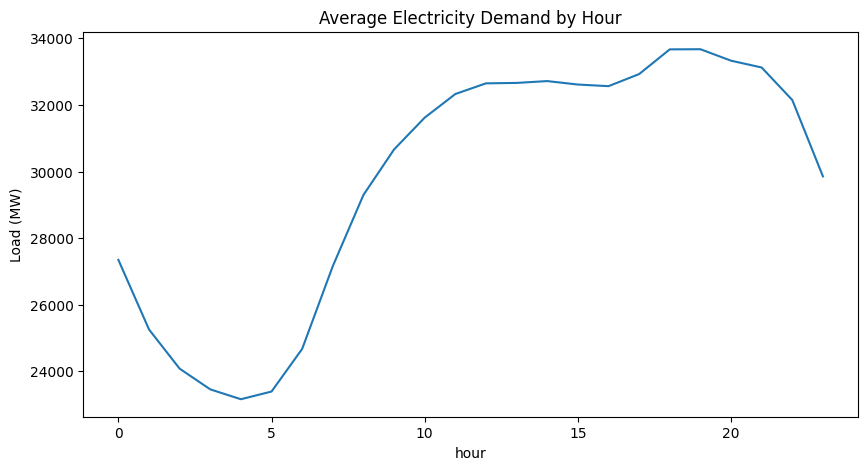

In [12]:
# average deman by hour

hourly_avg = (
    df.groupby("hour")["PJM_Load_MW"]
    .mean()
)

hourly_avg.plot(figsize=(10,5))

plt.title("Average Electricity Demand by Hour")
plt.ylabel("Load (MW)")
plt.show()

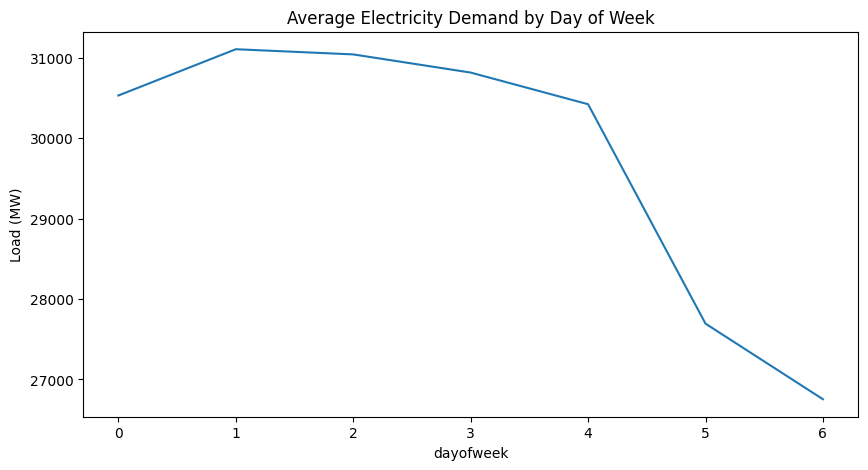

In [13]:
# average demand by day of the week

weekly_avg = (
    df.groupby("dayofweek")["PJM_Load_MW"]
    .mean()
)

weekly_avg.plot(figsize=(10,5))

plt.title("Average Electricity Demand by Day of Week")
plt.ylabel("Load (MW)")
plt.show()

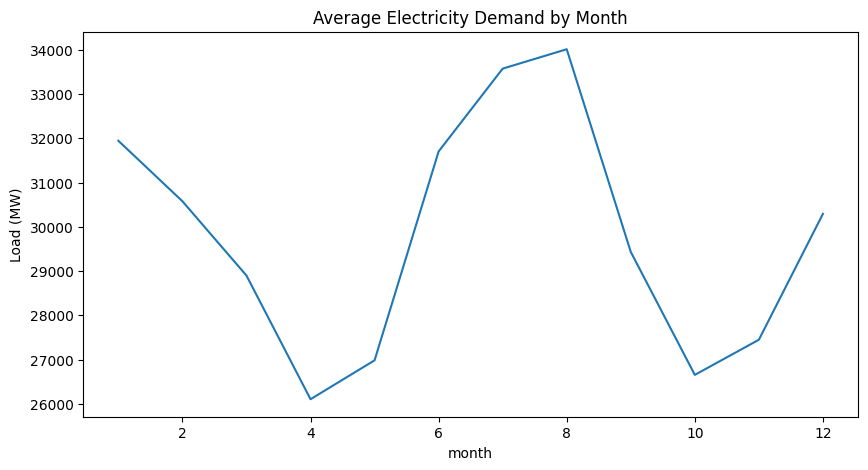

In [14]:
# average demand by monthh
monthly_avg = (
    df.groupby("month")["PJM_Load_MW"]
    .mean()
)

monthly_avg.plot(figsize=(10,5))

plt.title("Average Electricity Demand by Month")
plt.ylabel("Load (MW)")
plt.show()

## Correlation Analysis

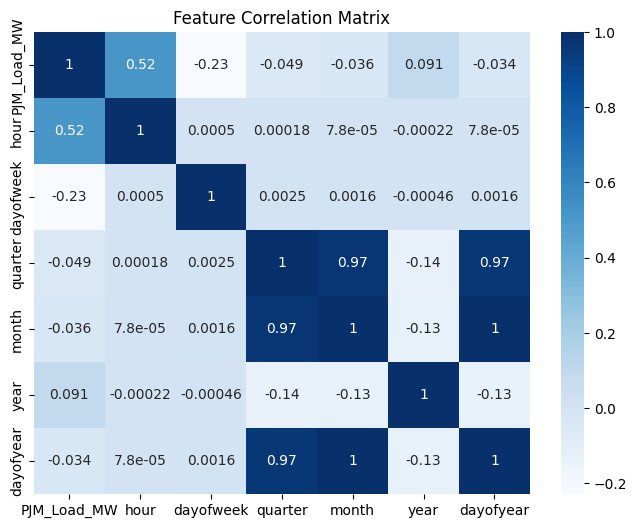

In [15]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation Matrix")
plt.show()

 ## Feature Engineering for Forecasting